# Разведочный анализ данных (EDA). Свойства композиционных материалов

**Целевые переменные:**
- Модуль упругости при растяжении, ГПа
- Прочность при растяжении, МПа

## 1. Загрузка и объединение данных
Датасет состоит из двух файлов:
- `X_bp.xlsx`
- `X_nup.xlsx`

Объединение выполняется по индексу, тип объединения — INNER, как указано в задании.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
RANDOM_STATE = 42

df1 = pd.read_excel('X_bp.xlsx')
df2 = pd.read_excel('X_nup.xlsx')

print('X_bp:', df1.shape)
print('X_nup:', df2.shape)

df = pd.merge(df1, df2, on = 'id', how='inner')
df = df.drop('id', axis=1)

print('Объединённый датасет:', df.shape)
df.head()

X_bp: (1023, 11)
X_nup: (1040, 4)
Объединённый датасет: (1023, 13)


,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,1.857143,2030.0,738.736842,30.00,22.267857,100.000000,210.0,70.0,3000.0,220.0,0,4.0,57.0
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,60.0
2,1.857143,2030.0,738.736842,49.90,33.000000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,70.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0,0,5.0,47.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,57.0


## 2. Первичный осмотр

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       1023 non-null   float64
 1   Плотность, кг/м3                      1023 non-null   float64
 2   модуль упругости, ГПа                 1023 non-null   float64
 3   Количество отвердителя, м.%           1023 non-null   float64
 4   Содержание эпоксидных групп,%_2       1023 non-null   float64
 5   Температура вспышки, С_2              1023 non-null   float64
 6   Поверхностная плотность, г/м2         1023 non-null   float64
 7   Модуль упругости при растяжении, ГПа  1023 non-null   float64
 8   Прочность при растяжении, МПа         1023 non-null   float64
 9   Потребление смолы, г/м2               1023 non-null   float64
 10  Угол нашивки, град                    1023 non-null   int64  
 11  Шаг нашивки                 

In [3]:
df.shape

(1023, 13)

### Проверка пропусков и дубликатов

In [4]:
print('Количество пропусков:', df.isna().sum().sum())
print('Количество полных дубликатов строк:', df.duplicated().sum())

Количество пропусков: 0
Количество полных дубликатов строк: 0


### Описательная статистика

In [5]:
df.describe()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
count,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000
mean,2.930366,1975.734888,739.923233,110.570769,22.244390,285.882151,482.731833,73.328571,2466.922843,218.423144,44.252199,6.899222,57.153929
std,0.913222,73.729231,330.231581,28.295911,2.406301,40.943260,281.314690,3.118983,485.628006,59.735931,45.015793,2.563467,12.350969
min,0.389403,1731.764635,2.436909,17.740275,14.254985,100.000000,0.603740,64.054061,1036.856605,33.803026,0.000000,0.000000,0.000000
25%,2.317887,1924.155467,500.047452,92.443497,20.608034,259.066528,266.816645,71.245018,2135.850448,179.627520,0.000000,5.080033,49.799212
50%,2.906878,1977.621657,739.664328,110.564840,22.230744,285.896812,451.864365,73.268805,2459.524526,219.198882,0.000000,6.916144,57.341920
75%,3.552660,2021.374375,961.812526,129.730366,23.961934,313.002106,693.225017,75.356612,2767.193119,257.481724,90.000000,8.586293,64.944961
max,5.591742,2207.773481,1911.536477,198.953207,33.000000,413.273418,1399.542362,82.682051,3848.436732,414.590628,90.000000,14.440522,103.988901


**Выводы по первичному осмотру:**
- объём выборки — 1023 наблюдения, 13 признаков (11 входных и 2 целевые переменные);
- пропуски и полные дубликаты строк отсутствуют;
- все признаки числовые;
- признак «Угол нашивки, град» принимает только два значения (0 и 90), поэтому является категориальным, несмотря на числовой тип — при предобработке его следует закодировать как категориальный.

## 3. Разведочный анализ данных (EDA)

### 3.1. Распределения признаков

Построим гистограммы распределения для каждого признака. Признак «Угол нашивки, град» исключён, так как он категориальный.

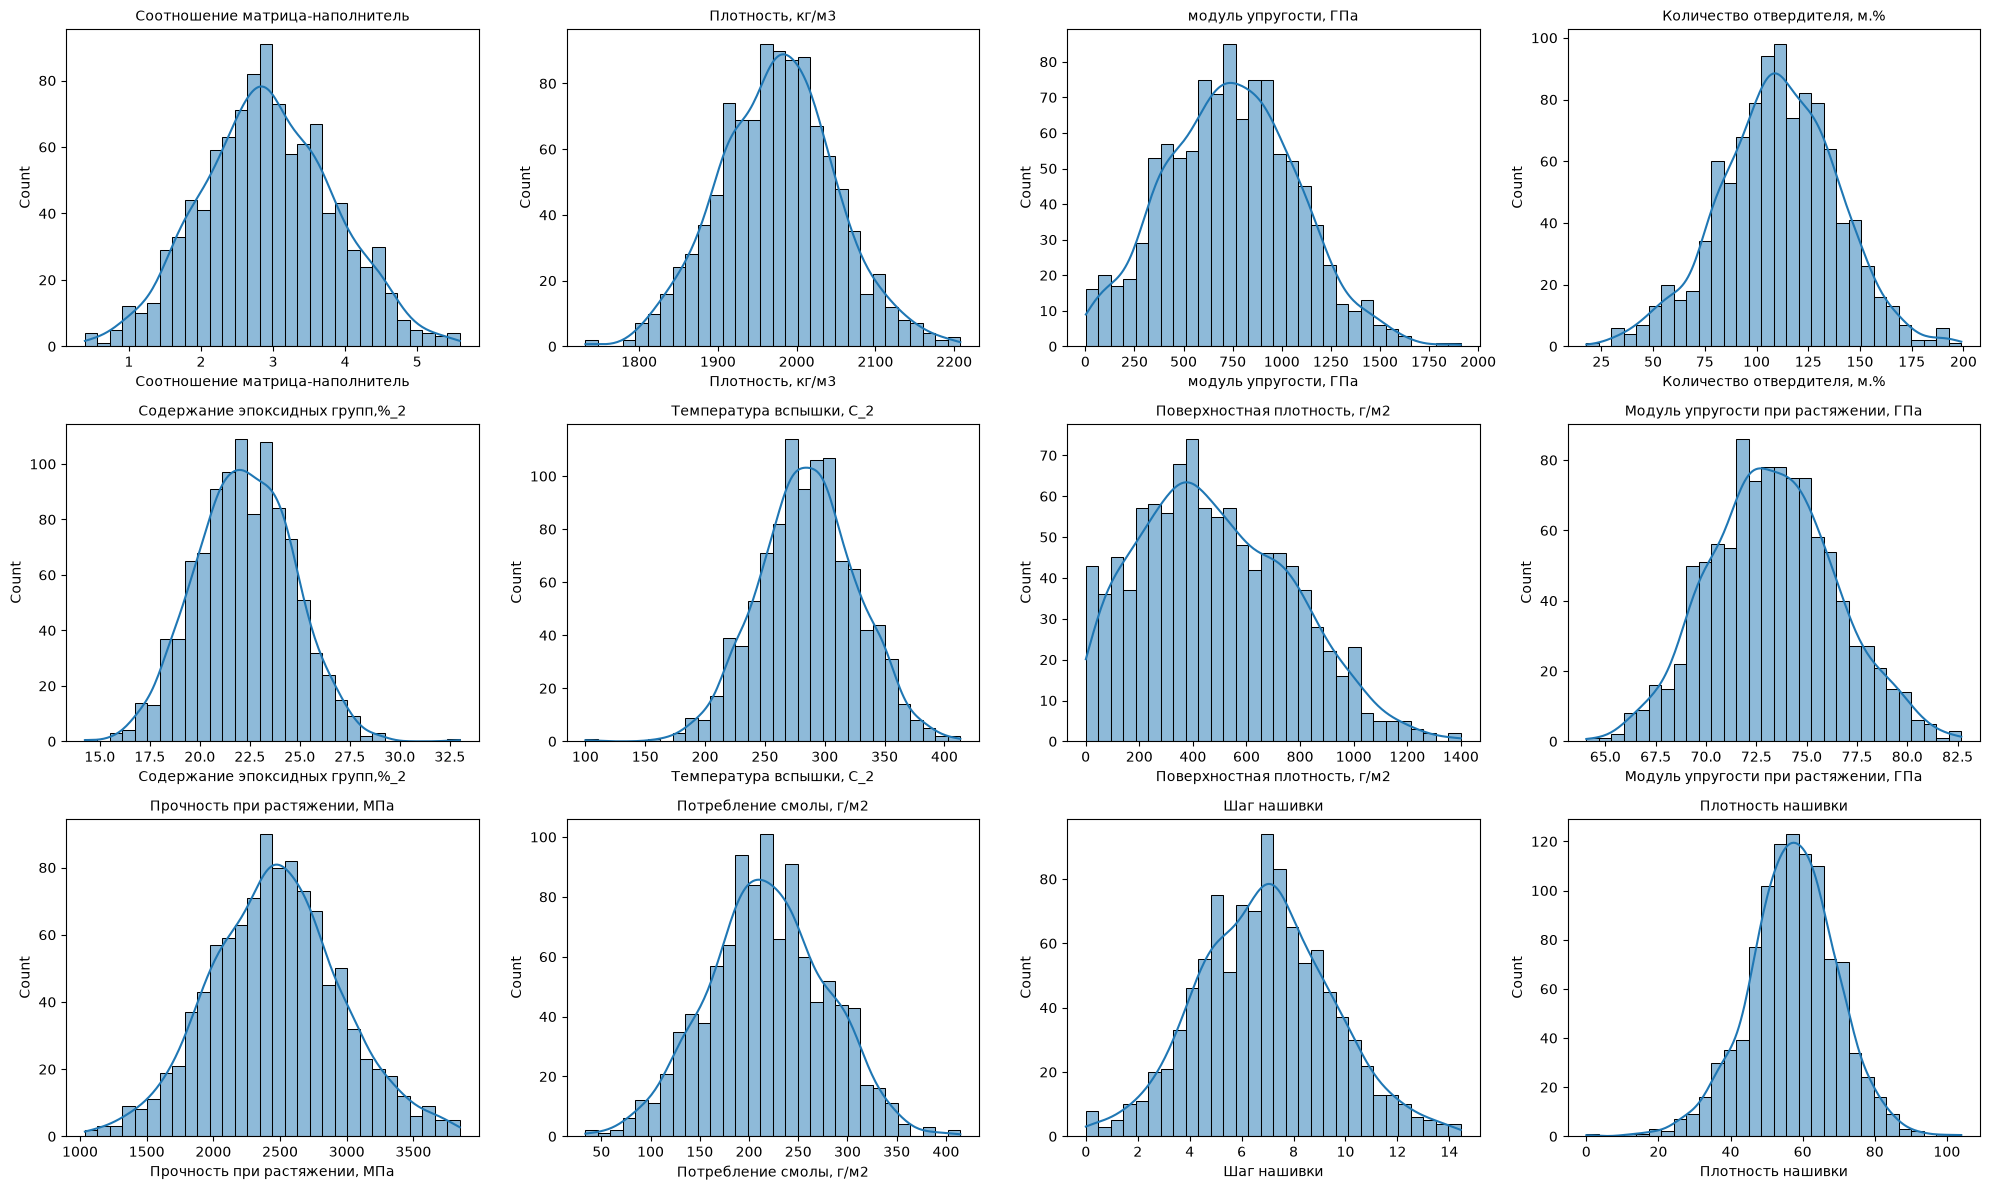

In [6]:
cols = df.columns.tolist()
cols.remove('Угол нашивки, град')

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for ax, col in zip(axes.ravel(), cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

**Выводы по распределениям:**
- распределения большинства признаков симметричны, но некоторые имеют «тяжёлые хвосты» — это необходимо учитывать при нормализации;

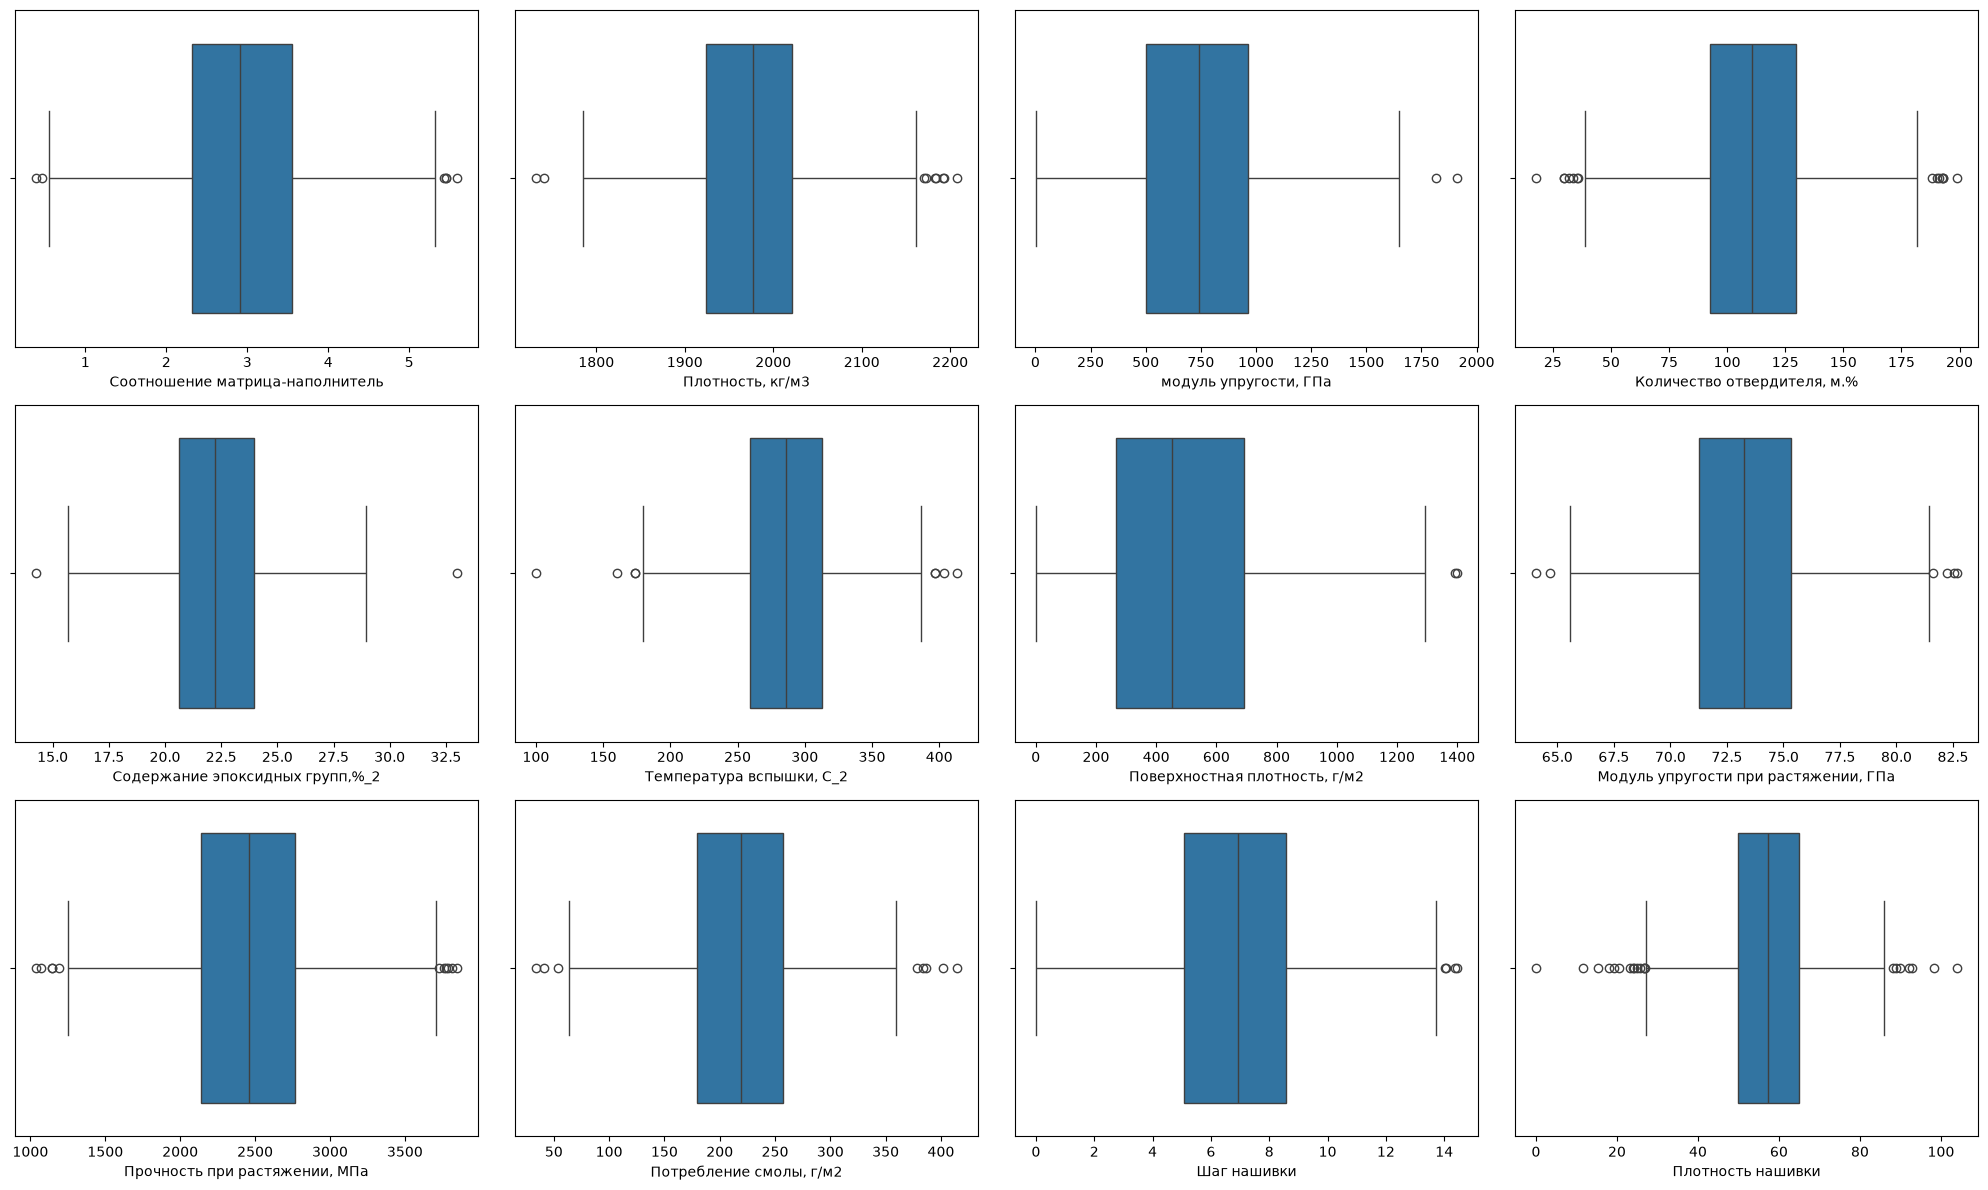

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12)) 

for ax, col in zip(axes.ravel(), cols):
    sns.boxplot(x=df[col], ax=ax)

plt.tight_layout()
plt.show()

Было замечено значение 0 в плотности нашивки, что вроде как не возможно, поэтому с этим предпологаемым пропуском надо поработать отдельно

In [8]:
p_patch = df[(df['Плотность нашивки'] == 0)]
p_patch

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
19,3.532338,1980.0,1183.0,111.86,22.267857,284.615385,1010.0,78.0,2000.0,300.0,0,0.0,0.0


In [9]:
st_patch = df[df['Шаг нашивки'] == 0] 
st_patch


,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
19,3.532338,1980.0,1183.0,111.86,22.267857,284.615385,1010.0,78.0,2000.0,300.0,0,0.0,0.0


Дополнительный анализ показал, что данное значение не является пропуском и оно получилось в результате того что шаг нашивки тоже 0

### 3.3. Анализ выбросов

Для оценки выбросов применим правило межквартильного размаха.

In [10]:
for col in cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < low) | (df[col] > high)]
    print(f'{col}: кондидатов в выбросы: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

Соотношение матрица-наполнитель: кондидатов в выбросы: 6 (0.6%)
Плотность, кг/м3: кондидатов в выбросы: 9 (0.9%)
модуль упругости, ГПа: кондидатов в выбросы: 2 (0.2%)
Количество отвердителя, м.%: кондидатов в выбросы: 14 (1.4%)
Содержание эпоксидных групп,%_2: кондидатов в выбросы: 2 (0.2%)
Температура вспышки, С_2: кондидатов в выбросы: 8 (0.8%)
Поверхностная плотность, г/м2: кондидатов в выбросы: 2 (0.2%)
Модуль упругости при растяжении, ГПа: кондидатов в выбросы: 6 (0.6%)
Прочность при растяжении, МПа: кондидатов в выбросы: 11 (1.1%)
Потребление смолы, г/м2: кондидатов в выбросы: 8 (0.8%)
Шаг нашивки: кондидатов в выбросы: 4 (0.4%)
Плотность нашивки: кондидатов в выбросы: 21 (2.1%)


Выбросы, выявленные по правилу межквартильного размаха, составляют не более двух процентов выборки по каждому признаку. Содержательный анализ показывает, что все эти значения физически правдоподобны, поэтому удалять их нецелесообразно — они несут информацию о редких, но возможных составах композитов.

Отдельного внимания заслуживает признак «Плотность нашивки»: в данных присутствует значение, равное нулю.

In [11]:
df[df['Плотность нашивки'] == 0]

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
19,3.532338,1980.0,1183.0,111.86,22.267857,284.615385,1010.0,78.0,2000.0,300.0,0,0.0,0.0


In [12]:
zero_share = (df['Плотность нашивки'] == 0).sum() * 100 / len(df)
print(f'Доля записей с нулевой плотностью нашивки: {zero_share:.2f} %')

Доля записей с нулевой плотностью нашивки: 0.10 %


Нулевая плотность нашивки физически невозможна; дополнительный анализ показал, что у этой же записи нулевой и шаг нашивки, что указывает на ошибку регистрации, а не на реальный состав. Поскольку такая запись одна (0,1 процента выборки), принято решение исключить её из дальнейшего анализа.

In [13]:
df = df[df['Плотность нашивки'] > 0].reset_index(drop=True)
print('Размер выборки после удаления ошибочной записи:', df.shape)

Размер выборки после удаления ошибочной записи: (1022, 13)


### 3.4. Попарные графики рассеяния

Построим попарные графики рассеяния признаков с раскраской по значению угла нашивки.

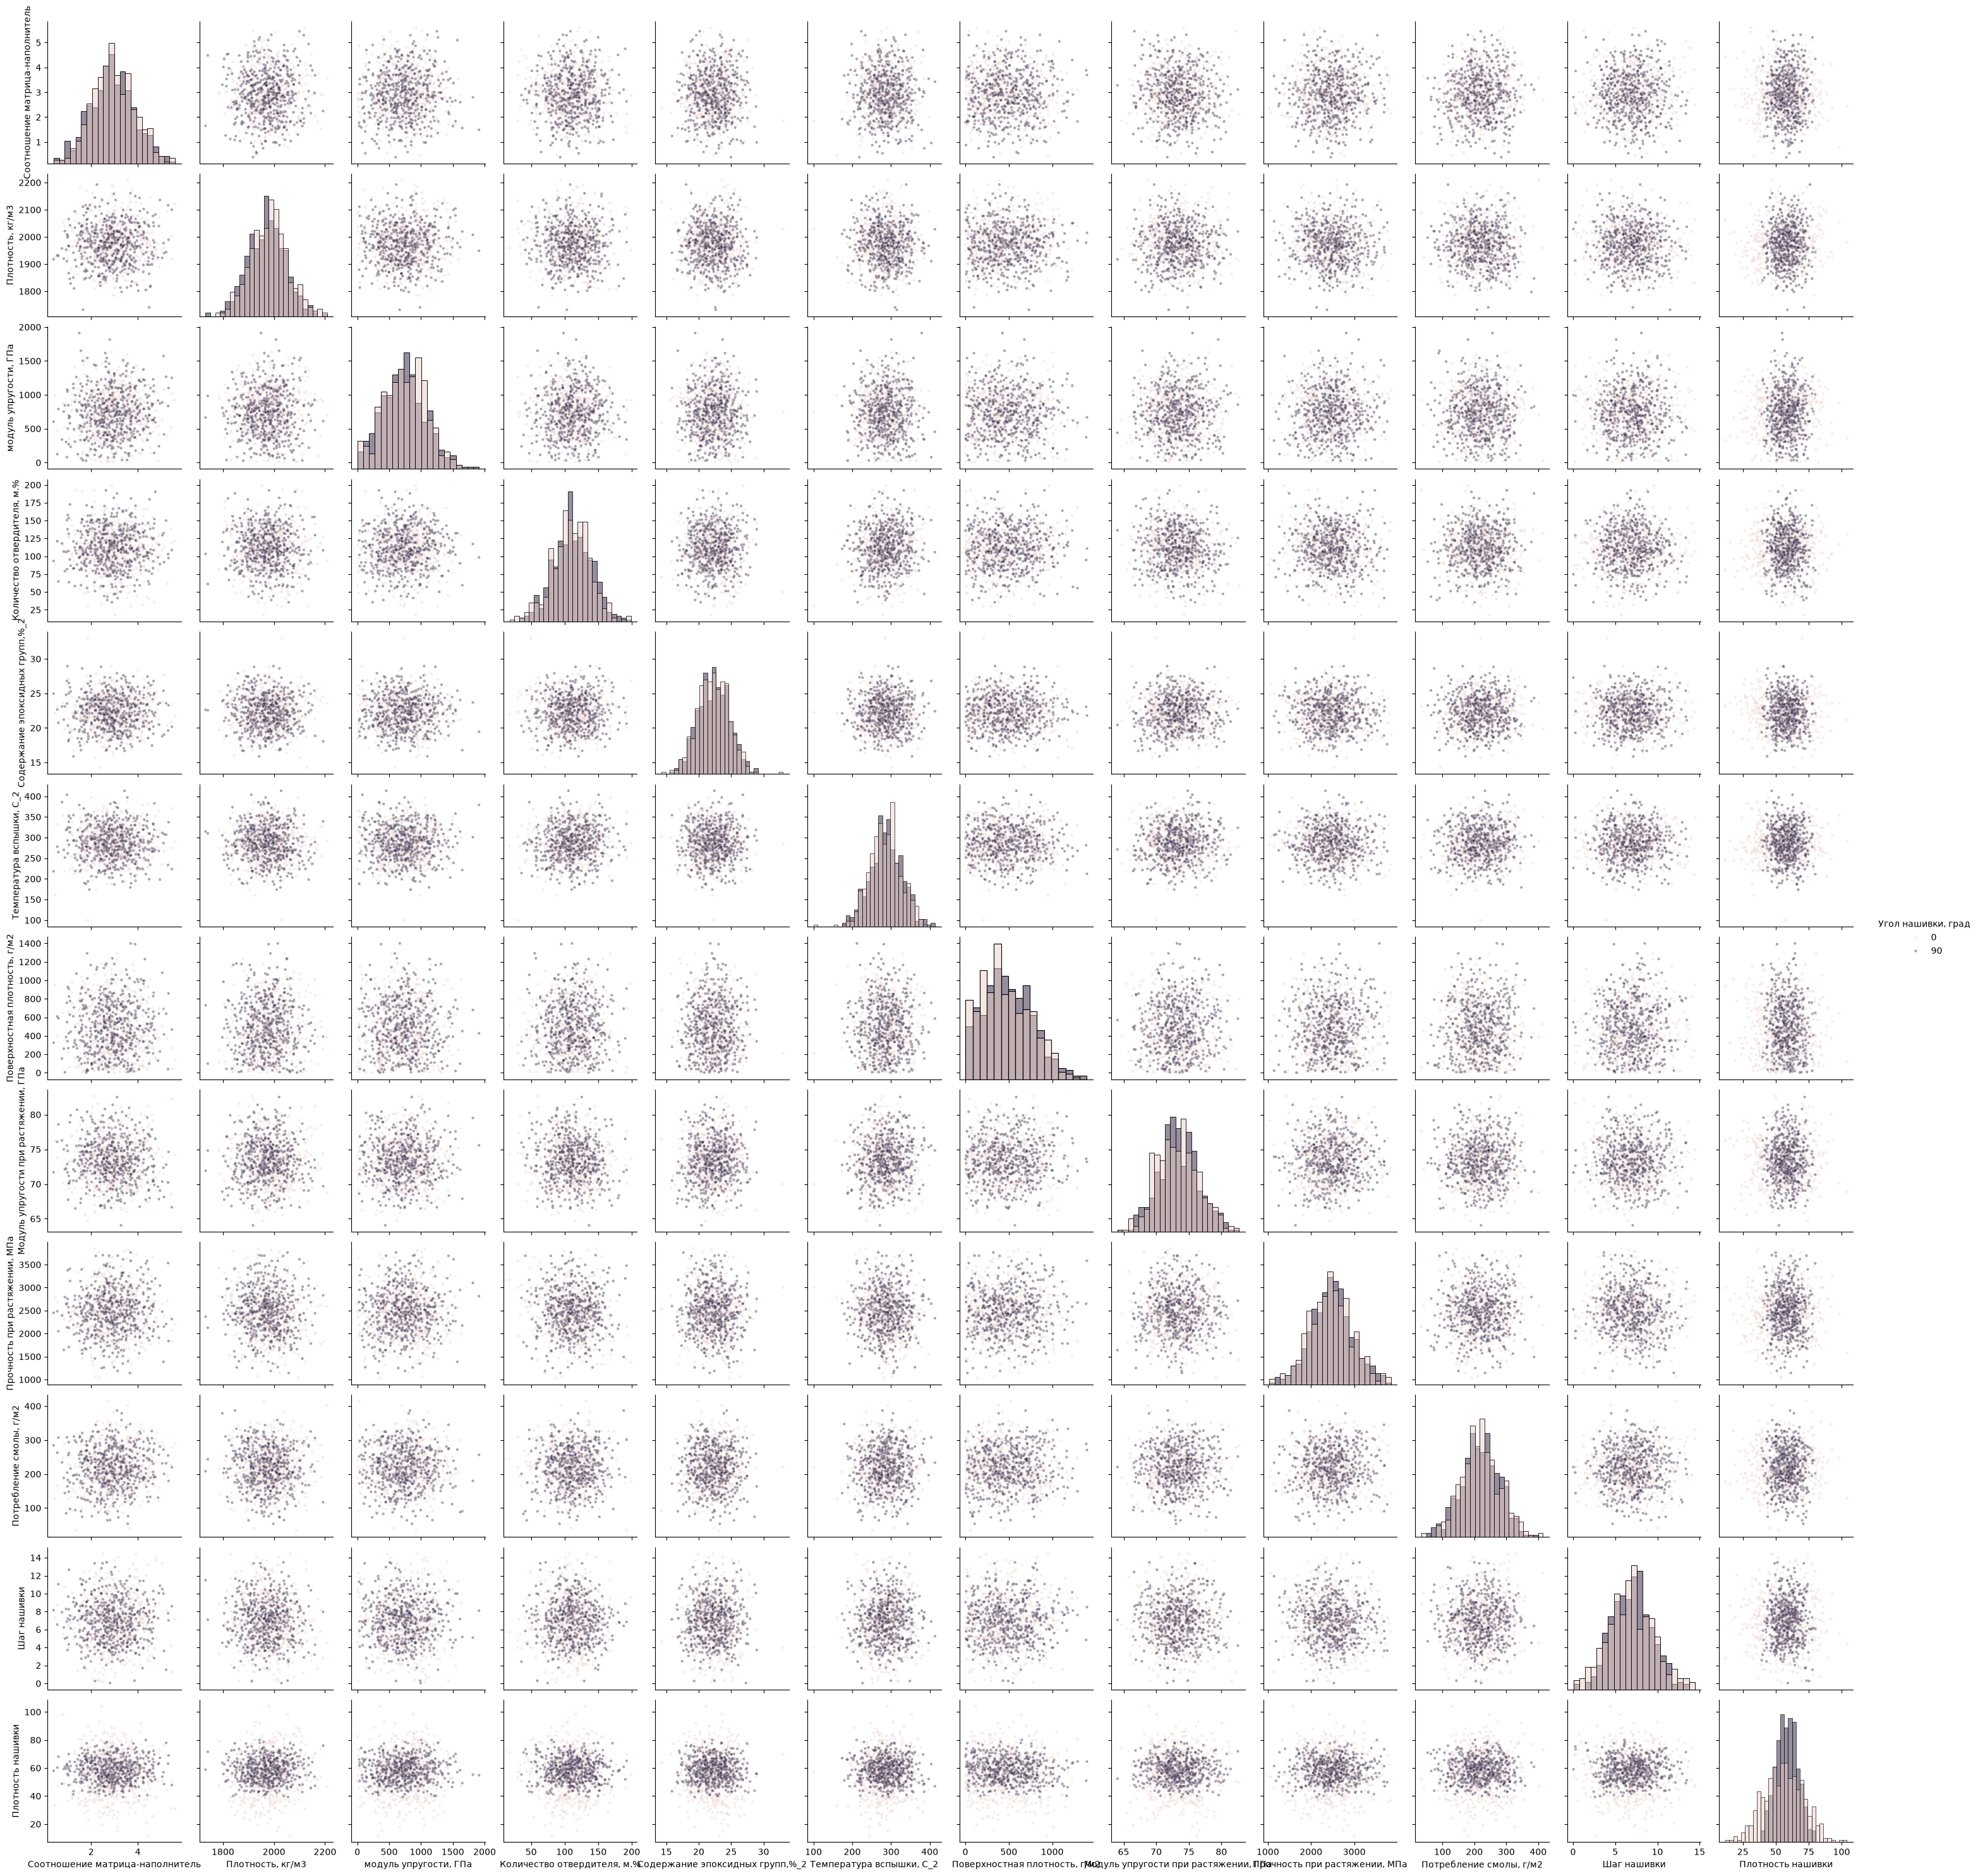

In [14]:
sns.pairplot(df, hue='Угол нашивки, град', diag_kind='hist',
             plot_kws={'alpha': 0.4, 's': 10})
plt.show()

**Выводы по попарным графикам:**
- явных линейных зависимостей между признаками не наблюдается - облака точек преимущественно бесструктурны;
- группы с углом нашивки 0 и 90 градусов на ряде графиков визуально различаются, что говорит о потенциальной информативности этого признака;
- зависимость целевых переменных от входных факторов, по-видимому, нелинейная, поэтому наряду с линейными моделями следует рассматривать нелинейные.

### Корреляция числовых признаков

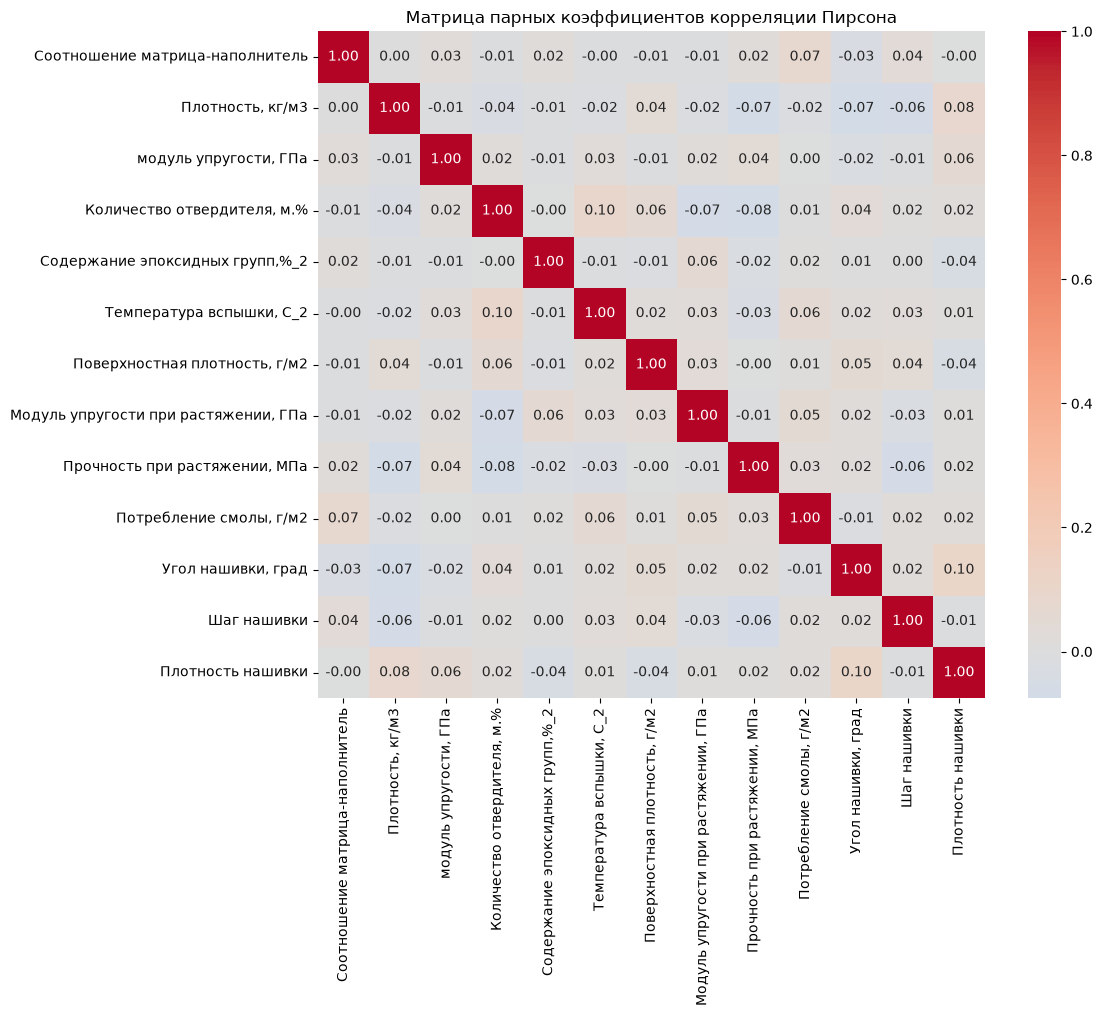

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица парных коэффициентов корреляции Пирсона')
plt.tight_layout()
plt.show()

**Выводы по корреляционному анализу:**
- сильных линейных корреляций между признаками не выявлено: все парные коэффициенты корреляции по модулю меньше 0,5, следовательно, мультиколлинеарность отсутствует, и удалять признаки по этому критерию не требуется;
- слабая корреляция входных признаков с целевыми переменными подтверждает нелинейный характер зависимостей и необходимость применения нелинейных моделей.

## 2.1. Предобработка данных

### Бинарное кодирование признака «Угол нашивки, град»

Признак принимает только два значения (0 и 90 градусов). Для бинарного признака замена значений на 0 и 1 эквивалентна one-hot кодированию (из двух one-hot колонок одна всегда избыточна), поэтому применяем простую замену: 0 → 0, 90 → 1.

In [16]:
df['Угол нашивки, град'] = df['Угол нашивки, град'].replace(90, 1)
df['Угол нашивки, град']

0       0
1       0
2       0
3       0
4       0
       ..
1017    1
1018    1
1019    1
1020    1
1021    1
Name: Угол нашивки, град, Length: 1022, dtype: int64

Нормализация

In [17]:
targets = ['Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа']

# Из признаков убираем ОБЕ целевые переменные — иначе одна целевая «подсматривает» в другую (утечка данных)
X = df.drop(columns=targets)

y_elasticity = df['Модуль упругости при растяжении, ГПа']
y_strength = df['Прочность при растяжении, МПа']

print('Признаков в X:', X.shape[1])
print(X.columns.tolist())

Признаков в X: 11
['Соотношение матрица-наполнитель', 'Плотность, кг/м3', 'модуль упругости, ГПа', 'Количество отвердителя, м.%', 'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2', 'Поверхностная плотность, г/м2', 'Потребление смолы, г/м2', 'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки']


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Общий X, одинаковый random_state — строки в обоих сплитах совпадают
X_train, X_test, y_elasticity_train, y_elasticity_test = train_test_split(
    X, y_elasticity, test_size=0.3, random_state=RANDOM_STATE)

_, _, y_strength_train, y_strength_test = train_test_split(
    X, y_strength, test_size=0.3, random_state=RANDOM_STATE)

# Отдельный скейлер под каждую задачу
scaler_elasticity = MinMaxScaler()
X_elasticity_train_scaled = scaler_elasticity.fit_transform(X_train)
X_elasticity_test_scaled = scaler_elasticity.transform(X_test)

scaler_strength = MinMaxScaler()
X_strength_train_scaled = scaler_strength.fit_transform(X_train)
X_strength_test_scaled = scaler_strength.transform(X_test)

Графики распределения после нормализации

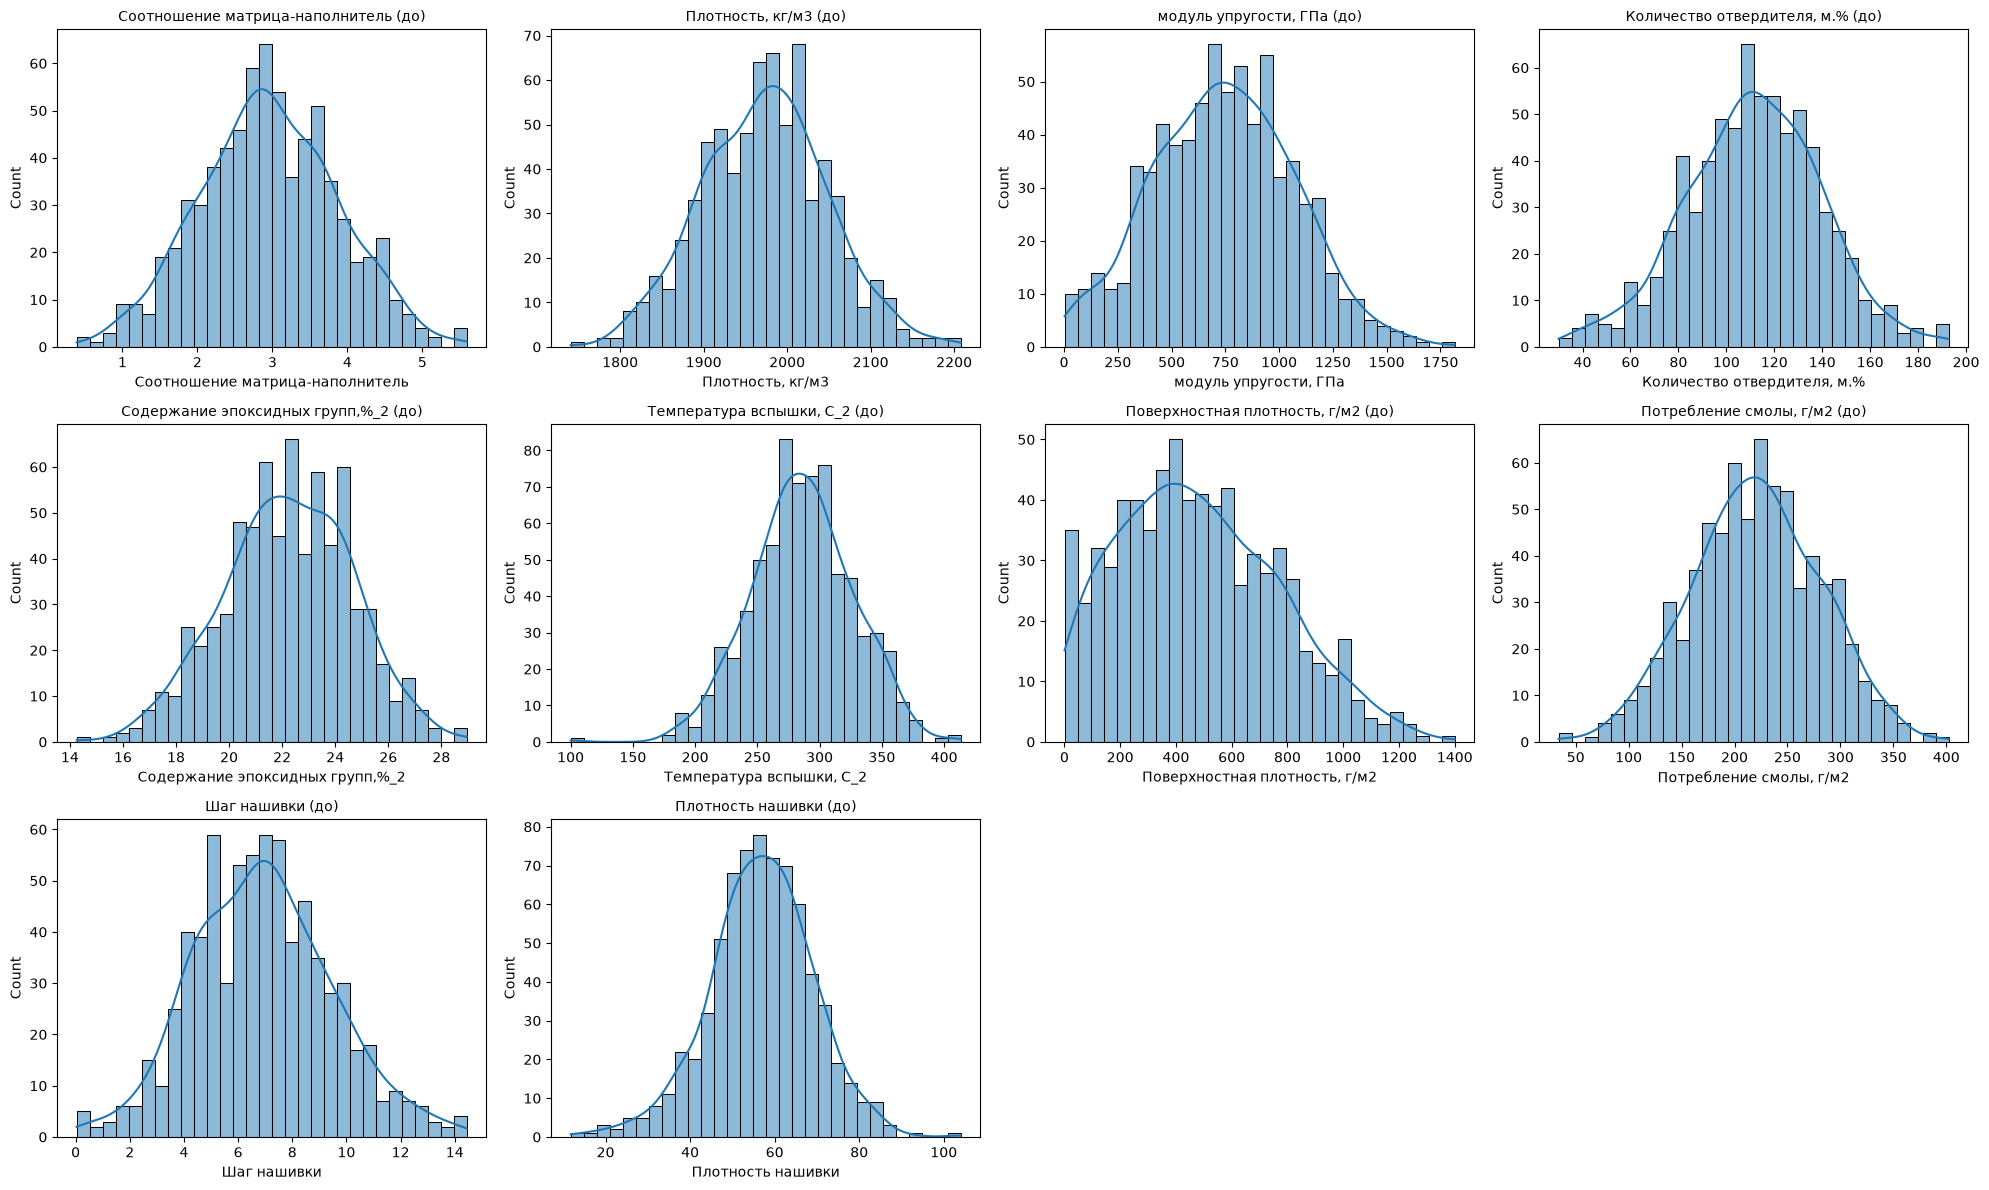

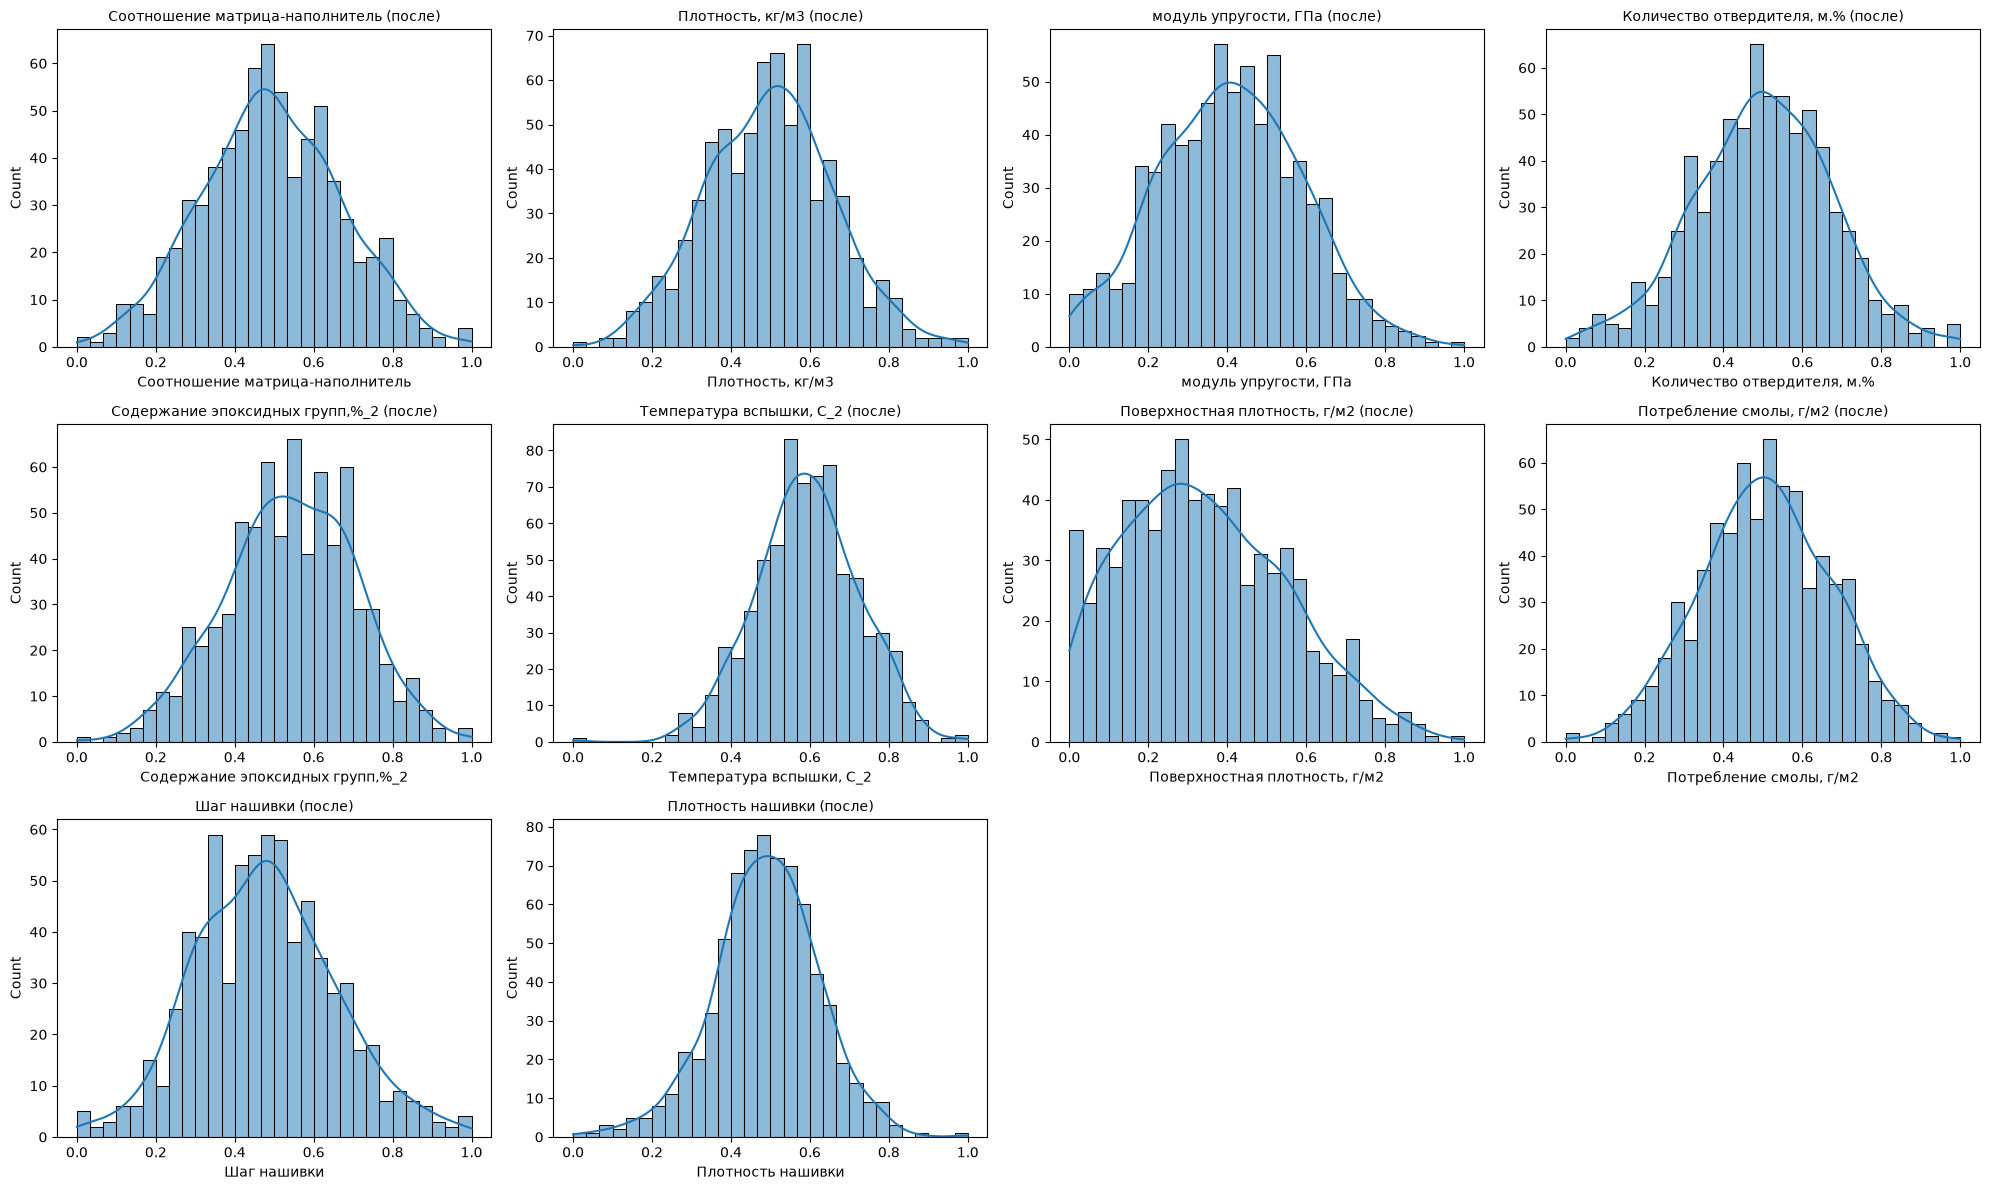

In [19]:
# Оборачиваем нормализованный массив обратно в DataFrame
X_train_scaled_df = pd.DataFrame(
    X_elasticity_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

cols_plot = X_train.columns.tolist()
cols_plot.remove('Угол нашивки, град')   # бинарный признак (0/1), на графиках не нужен

# До нормализации
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.ravel(), cols_plot):
    sns.histplot(X_train[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'{col} (до)', fontsize=10)
for ax in axes.ravel()[len(cols_plot):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

# После нормализации
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.ravel(), cols_plot):
    sns.histplot(X_train_scaled_df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'{col} (после)', fontsize=10)
for ax in axes.ravel()[len(cols_plot):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [20]:
# Минимальные и максимальные значения до и после нормализации
summary = pd.DataFrame({
    'min_до': X_train.min(),
    'max_до': X_train.max(),
    'min_после': X_train_scaled_df.min(),
    'max_после': X_train_scaled_df.max()
})
summary.round(3)

,min_до,max_до,min_после,max_после
Соотношение матрица-наполнитель,0.389,5.592,0.0,1.0
"Плотность, кг/м3",1740.657,2207.773,0.0,1.0
"модуль упругости, ГПа",2.437,1815.865,0.0,1.0
"Количество отвердителя, м.%",30.000,192.705,0.0,1.0
"Содержание эпоксидных групп,%_2",14.255,28.955,0.0,1.0
"Температура вспышки, С_2",100.000,413.273,0.0,1.0
"Поверхностная плотность, г/м2",0.604,1399.542,0.0,1.0
"Потребление смолы, г/м2",33.803,402.164,0.0,1.0
"Угол нашивки, град",0.000,1.000,0.0,1.0
Шаг нашивки,0.038,14.441,0.0,1.0


## 2.2. Разработка и обучение моделей

In [21]:
# Импорт
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

In [30]:
# Pipeline
models = {
    'Линейная регрессия': (LinearRegression(), {}),
    'Случайный лес': (RandomForestRegressor(random_state=RANDOM_STATE), {'model__n_estimators': [100, 200], 'model__max_depth': [5, 10, None]}),
    'Градиентный бустинг': (GradientBoostingRegressor(random_state=RANDOM_STATE), {'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1], 
                                                                                   'model__max_depth': [3, 5]}),
    'k ближайших': (KNeighborsRegressor(), {'model__n_neighbors': [3, 5, 7, 9], 'model__weights': ['uniform', 'distance']})
}

targets = {
    'Модуль упругости при растяжении, ГПа': (y_elasticity_train, y_elasticity_test),
    'Прочность при растяжении, МПа': (y_strength_train, y_strength_test),
}

results = []
best_pipelines = {}

for tar_name, (y_tr, y_te) in targets.items():
    for mod_name, (model, grid) in models.items():
        pipe = Pipeline([
            ('scaler', MinMaxScaler()),
            ('model', model)])
        search = GridSearchCV(pipe, grid, cv=10, scoring='neg_mean_absolute_error', n_jobs=-1)
        search.fit(X_train, y_tr)

        best = search.best_estimator_
        best_pipelines[(tar_name, mod_name)] = best

        pred_tr, pred_te = best.predict(X_train), best.predict(X_test)

        results.append({
            'Целевая перпеменная': tar_name,
            'Модель': mod_name,
            'MAE train': mean_absolute_error(y_tr, pred_tr),
            'MAE test': mean_absolute_error(y_te, pred_te),
            'RMSE train': np.sqrt(mean_squared_error(y_tr, pred_tr)),
            'RMSE test': np.sqrt(mean_squared_error(y_te, pred_te)),
            'R² train': r2_score(y_tr, pred_tr),
            'R² test': r2_score(y_te, pred_te),
        })

        print(f'{tar_name} | {mod_name} лучшие параметры:{search.best_params_}')

    results_df = pd.DataFrame(results)

Модуль упругости при растяжении, ГПа | Линейная регрессия лучшие параметры:{}
Модуль упругости при растяжении, ГПа | Случайный лес лучшие параметры:{'model__max_depth': 5, 'model__n_estimators': 200}
Модуль упругости при растяжении, ГПа | Градиентный бустинг лучшие параметры:{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Модуль упругости при растяжении, ГПа | k ближайших лучшие параметры:{'model__n_neighbors': 9, 'model__weights': 'uniform'}
Прочность при растяжении, МПа | Линейная регрессия лучшие параметры:{}
Прочность при растяжении, МПа | Случайный лес лучшие параметры:{'model__max_depth': 5, 'model__n_estimators': 100}
Прочность при растяжении, МПа | Градиентный бустинг лучшие параметры:{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Прочность при растяжении, МПа | k ближайших лучшие параметры:{'model__n_neighbors': 9, 'model__weights': 'uniform'}


In [31]:
results_df.round(3)

,Целевая перпеменная,Модель,MAE train,MAE test,RMSE train,RMSE test,R² train,R² test
0,"Модуль упругости при растяжении, ГПа",Линейная регрессия,2.539,2.370,3.156,2.945,0.020,-0.004
1,"Модуль упругости при растяжении, ГПа",Случайный лес,2.237,2.364,2.756,2.957,0.253,-0.012
2,"Модуль упругости при растяжении, ГПа",Градиентный бустинг,2.160,2.365,2.685,2.988,0.291,-0.034
3,"Модуль упругости при растяжении, ГПа",k ближайших,2.493,2.478,3.089,3.130,0.061,-0.134
4,"Прочность при растяжении, МПа",Линейная регрессия,371.596,403.814,473.351,503.319,0.025,-0.036
5,"Прочность при растяжении, МПа",Случайный лес,331.823,396.874,418.905,496.342,0.237,-0.007
6,"Прочность при растяжении, МПа",Градиентный бустинг,317.329,402.110,404.349,502.146,0.289,-0.031
7,"Прочность при растяжении, МПа",k ближайших,357.917,419.484,455.540,524.283,0.097,-0.124


Сравнительный анализ метрик показал для переменной "Модуль упругости при растяжении, ГПа", что R2 для этого датасета не подходит так как на этапе EDA было выясненно что корелаций практически нету, а все зависимости нелинейные. Исходя из этого лучшая модель по метрикам MAE и RMSE является "Линейная регрессия", но в целом разница между этими моделями небольшая (кареляция составляет менее 1 %).

Анализируя переменную "Прочность при растяжении, МПа" можно сделать такие же выводы как и по переменной "Модуль упругости при растяжении, ГПа" и в качестве лучшей модели выбрать также "Случайный лес" так как и по метрикам MAE и RMSE у него лучший результат, хотя дисперсия также является небольшой около 1.5%